# ใบงานที่ 3: Regression & Classification (วิเคราะห์ข้อมูล NBA)
**วิชา Machine Learning (04-624-201)**

---
### 🎯 วัตถุประสงค์ของใบงานนี้
ใบงานนี้จะใช้ **ชุดข้อมูลสถิตินักบาสเกตบอล NBA (Tabular Data)** แทนข้อมูลรูปภาพ เพื่อลดความซับซ้อนในการจัดการไฟล์ภาพ และเน้นไปที่กระบวนการทำ Machine Learning ตามโจทย์ของอาจารย์อย่างครบถ้วน ซึ่งประกอบด้วย:
1. **การลดมิติข้อมูล (PCA):** ลดจำนวนสถิติที่มีหลายคอลัมน์ให้เหลือน้อยลง แต่ยังคงข้อมูลสำคัญไว้
2. **LAB 1 - Linear Regression:** สร้างโมเดลทำนาย "คะแนนเฉลี่ยต่อเกม (PTS)" ของนักกีฬา
3. **LAB 2 - Logistic Regression:** สร้างโมเดลเพื่อจำแนก "ตำแหน่งการเล่น (Position)" ว่าเป็นวงนอก (Guard) หรือวงใน (Forward/Center)
4. **LAB 3 - Model Evaluation:** ประเมินประสิทธิภาพของโมเดลด้วยค่าสถิติต่างๆ และ ROC Curve

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # ปิดการแจ้งเตือนกวนใจ

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc

# กำหนดชื่อไฟล์ (เปลี่ยนชื่อตรงนี้ให้ตรงกับไฟล์ CSV ที่มีในโฟลเดอร์เดียวกัน)
file_name = 'nba_data_processed.csv' 

## 📂 ขั้นตอนที่ 1: โหลดข้อมูลและการเตรียมข้อมูล (Data Preprocessing)
ในขั้นตอนนี้เราจะนำเข้าไฟล์ CSV มาเก็บไว้ในตัวแปรตาราง (DataFrame) และทำการ **ทำความสะอาดข้อมูล (Data Cleaning)** 

**ปัญหาที่พบบ่อย:** ข้อมูลสถิติบางช่องอาจจะว่างเปล่า (NaN) เช่น นักกีฬาบางคนไม่เคยชู้ตลูก 3 แต้มเลย ทำให้ค่าเปอร์เซ็นต์เป็นค่าว่าง เราจึงต้องเติมเลข `0` ลงไปแทนค่าว่างเหล่านั้น 
*(หมายเหตุ: เราจะเติมเลข 0 เฉพาะคอลัมน์ที่เป็นตัวเลขเท่านั้น เพื่อป้องกัน Error จากการนำตัวเลขไปใส่คอลัมน์ที่เป็นข้อความอย่างชื่อคน)*

In [8]:
try:
    # โหลดไฟล์ข้อมูล
    df = pd.read_csv(file_name, encoding='utf-8', delimiter=';') 
    if len(df.columns) == 1:
         df = pd.read_csv(file_name, encoding='utf-8')
    print("✅ Data Loaded Successfully!\n")
    
    # เลือกเติมเลข 0 เฉพาะในคอลัมน์ที่เป็นตัวเลขเท่านั้น (แก้ปัญหา TypeError dtype 'str')
    numeric_cols = df.select_dtypes(include=['number']).columns
    df[numeric_cols] = df[numeric_cols].fillna(0)
    
    print(f"📌 Total shape: {df.shape[0]} rows, {df.shape[1]} columns")
    display(df.head(3))
except FileNotFoundError:
    print(f"❌ File not found: '{file_name}'")


✅ Data Loaded Successfully!

📌 Total shape: 705 rows, 29 columns


,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,Precious Achiuwa,C,23.0,TOR,55.0,12.0,20.7,3.6,7.3,0.485,...,0.702,1.8,4.1,6.0,0.9,0.6,0.5,1.1,1.9,9.2
1,Steven Adams,C,29.0,MEM,42.0,42.0,27.0,3.7,6.3,0.597,...,0.364,5.1,6.5,11.5,2.3,0.9,1.1,1.9,2.3,8.6
2,Bam Adebayo,C,25.0,MIA,75.0,75.0,34.6,8.0,14.9,0.540,...,0.806,2.5,6.7,9.2,3.2,1.2,0.8,2.5,2.8,20.4


## 📉 ขั้นตอนที่ 2: การทำ PCA (Principal Component Analysis)
ข้อมูล NBA มีคอลัมน์สถิติเยอะมาก (เช่น นาทีที่เล่น, ชู้ตลงกี่ลูก, รีบาวด์, แอสซิสต์ ฯลฯ) ซึ่งบางสถิติอาจจะซ้ำซ้อนกัน เราจึงใช้ **PCA** เพื่อยุบรวมคอลัมน์เหล่านี้ให้เหลือน้อยลง 

**ขั้นตอน:**
1. ดึงมาเฉพาะคอลัมน์ที่เป็น "ตัวเลข"
2. **StandardScaler:** ปรับสเกลข้อมูลให้มีมาตรฐานเดียวกัน (สมมติว่าแต้มมีหลักสิบ แต่เปอร์เซ็นต์มีหลักทศนิยม ต้องปรับให้สูสีกันก่อน)
3. **PCA:** สกัดข้อมูลใหม่โดยตั้งเป้าหมายว่า ต้องรักษาข้อมูล (Variance) ให้คงอยู่ถึง 95%

In [9]:
if 'df' in locals():
    # คัดเฉพาะคอลัมน์สถิติตัวเลขมาทำ PCA และตัดคอลัมน์ที่ไม่จำเป็น (Age, Rk) ออก
    features = df.select_dtypes(include=[np.number]).drop(columns=['Age', 'Rk'], errors='ignore') 
    
    # เก็บข้อมูล 'PTS' (แต้มเฉลี่ยต่อเกม) แยกไว้ต่างหาก เพื่อเอาไปใช้ทำนายผลใน LAB 1
    X_raw = features.drop(columns=['PTS'], errors='ignore')
    y_pts = df['PTS'].values if 'PTS' in df.columns else np.zeros(len(df))
    
    # ปรับสเกลข้อมูล (สำคัญมากสำหรับการทำ PCA)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    
    # สั่งทำ PCA (เก็บข้อมูลสำคัญไว้ 95%)
    pca = PCA(n_components=0.95, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    
    print(f"📊 Features before PCA: {X_scaled.shape[1]}")
    print(f"✨ Features after PCA: {X_pca.shape[1]}")


📊 Features before PCA: 24
✨ Features after PCA: 11


---
## 🧪 LAB 1: Regression (การทำนายค่าตัวเลขต่อเนื่อง)
**เป้าหมาย:** สร้างแบบจำลอง **Linear Regression** เพื่อทายว่านักกีฬาคนหนึ่งจะได้ **คะแนนเฉลี่ยกี่แต้ม (PTS)** โดยดูจากสถิติที่เหลือของเขา (ที่ถูกนำไปทำ PCA แล้ว)

**การประเมินผล (Metrics):**
- **R-squared ($R^2$):** ยิ่งเข้าใกล้ 1.0 แปลว่าโมเดลทำนายได้แม่นยำมาก
- **MSE (Mean Squared Error):** ยิ่งค่าน้อย แปลว่าโมเดลทายผิดพลาดน้อย

--- LAB 1: Linear Regression ---
✅ R-squared Score: 0.9918
✅ Mean Squared Error (MSE): 0.3633


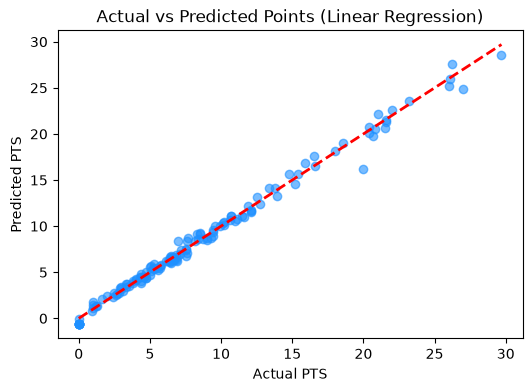

In [10]:
if 'df' in locals():
    # แบ่งข้อมูลเป็นชุดเรียนรู้ (Train) 80% และชุดทดสอบ (Test) 20%
    X_train_R, X_test_R, y_train_R, y_test_R = train_test_split(X_pca, y_pts, test_size=0.2, random_state=42)
    
    # สร้างโมเดล Linear Regression และสั่งให้เรียนรู้ (fit)
    model_reg = LinearRegression()
    model_reg.fit(X_train_R, y_train_R)
    
    # นำข้อสอบ (Test) ไปให้โมเดลทำนาย
    y_pred_R = model_reg.predict(X_test_R)
    
    # ตรวจคำตอบเทียบกับความจริง
    r2 = r2_score(y_test_R, y_pred_R)
    mse = mean_squared_error(y_test_R, y_pred_R)
    
    print("--- LAB 1: Linear Regression ---")
    print(f"✅ R-squared Score: {r2:.4f}")
    print(f"✅ Mean Squared Error (MSE): {mse:.4f}")
    
    # วาดกราฟเปรียบเทียบ
    plt.figure(figsize=(6, 4))
    plt.scatter(y_test_R, y_pred_R, alpha=0.6, color='dodgerblue')
    plt.plot([y_test_R.min(), y_test_R.max()], [y_test_R.min(), y_test_R.max()], 'r--', lw=2)
    plt.xlabel('Actual PTS')
    plt.ylabel('Predicted PTS')
    plt.title('Actual vs Predicted Points (Linear Regression)')
    plt.show()


---
## 🧪 LAB 2: Classification (การจำแนกหมวดหมู่)
**เป้าหมาย:** สร้างแบบจำลอง **Logistic Regression** เพื่อแยกแยะว่านักกีฬาคนนี้เล่นอยู่ **"วงนอก"** หรือ **"วงใน"** โดยดูจากสถิติของเขา

เราจะจัดกลุ่มคอลัมน์ตำแหน่ง (Pos) ใหม่ดังนี้:
- **0 = กลุ่ม Guard (การ์ดวงนอก):** ได้แก่ตำแหน่ง PG, SG
- **1 = กลุ่ม Forward/Center (ผู้เล่นวงใน):** ได้แก่ตำแหน่ง SF, PF, C

เราจะแสดงผลลัพธ์ในรูปแบบ **Confusion Matrix** เพื่อดูว่าโมเดลทายถูกทายผิดแบบไหนบ้าง

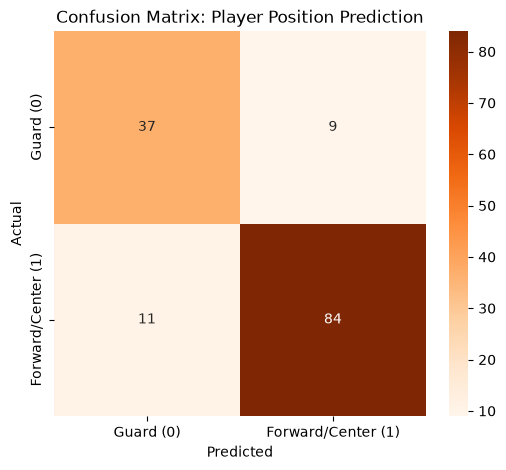

In [11]:
if 'df' in locals() and 'Pos' in df.columns:
    # สร้าง Label แบบ Binary (0 และ 1) สำหรับใช้จำแนกหมวดหมู่
    y_class = np.where(df['Pos'].str.contains('G'), 0, 1)
    
    # แบ่งข้อมูล Train 80% / Test 20%
    X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(X_pca, y_class, test_size=0.2, random_state=42)
    
    # สร้างโมเดล Logistic Regression
    model_clf = LogisticRegression(max_iter=1000)
    model_clf.fit(X_train_C, y_train_C)
    
    # สั่งให้โมเดลทำนาย (ผลลัพธ์เป็น 0 หรือ 1)
    y_pred_C = model_clf.predict(X_test_C)
    # สั่งให้โมเดลคายค่า 'ความมั่นใจ' (Probability) ออกมา เพื่อเอาไปวาด ROC Curve ใน LAB 3
    y_prob_C = model_clf.predict_proba(X_test_C)[:, 1]
    
    # สร้างตาราง Confusion Matrix
    cm = confusion_matrix(y_test_C, y_pred_C)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
                xticklabels=['Guard (0)', 'Forward/Center (1)'], 
                yticklabels=['Guard (0)', 'Forward/Center (1)'])
    plt.title('Confusion Matrix: Player Position Prediction')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
else:
    print("❌ ไม่พบคอลัมน์ 'Pos' ไม่สามารถทำ Classification ได้")


---
## 🧪 LAB 3: Model Evaluation (การประเมินประสิทธิภาพโมเดล Classification)
ในแล็บสุดท้าย เราจะนำผลการทำนายตำแหน่งจาก LAB 2 มาประเมินหาค่าสถิติต่างๆ เพื่อดูว่าโมเดลเก่งแค่ไหน:

1. **Accuracy (ความแม่นยำรวม):** ทายถูกทั้งหมดกี่เปอร์เซ็นต์
2. **Precision:** เมื่อทายว่าเป็นวงใน (1) ทายถูกจริงๆ เท่าไหร่
3. **Recall:** จากวงใน (1) ทั้งหมดที่มี โมเดลหาเจอเท่าไหร่
4. **F1-score:** ค่าเฉลี่ยแบบพิเศษที่บาลานซ์ระหว่าง Precision และ Recall
5. **ROC Curve & AUC:** กราฟประเมินการแบ่งแยกคลาส ยิ่งเส้นโค้งป่องขึ้นไปใกล้ 1.0 ด้านซ้ายบน ยิ่งแปลว่าโมเดลยอดเยี่ยม

--- Model Evaluation ---
🎯 Accuracy:  0.8582
🎯 Precision: 0.9032
🎯 Recall:    0.8842
🎯 F1-score:  0.8936



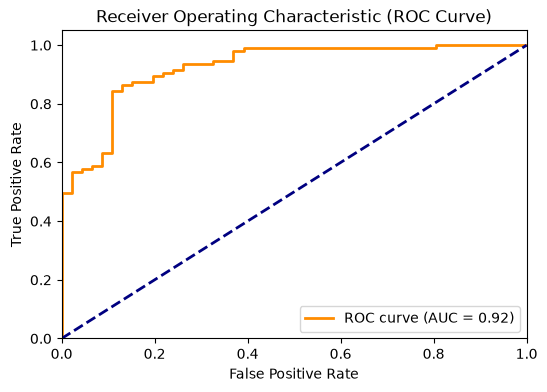

In [12]:
if 'df' in locals() and 'Pos' in df.columns:
    # คำนวณค่า Metrics ต่างๆ
    acc = accuracy_score(y_test_C, y_pred_C)
    prec = precision_score(y_test_C, y_pred_C)
    rec = recall_score(y_test_C, y_pred_C)
    f1 = f1_score(y_test_C, y_pred_C)
    
    print("--- Model Evaluation ---")
    print(f"🎯 Accuracy:  {acc:.4f}")
    print(f"🎯 Precision: {prec:.4f}")
    print(f"🎯 Recall:    {rec:.4f}")
    print(f"🎯 F1-score:  {f1:.4f}\n")
    
    # วาดกราฟ ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test_C, y_prob_C)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC Curve)')
    plt.legend(loc="lower right")
    plt.show()
